In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/telco_churn_processed.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,num_services,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,0,1,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,2,True,False,False,True,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,2,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,3,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,0,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False


In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,num_services,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,1,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,2,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,2,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,3,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,0,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # supports l1 + l2
    'class_weight': ['balanced']
}

from sklearn.model_selection import GridSearchCV

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',   # VERY important for churn
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [ ]:
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8466539720586163


In [8]:
best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(X_test_scaled)
y_pred_proba = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.7338537970191625
Precision: 0.49915397631133673
Recall: 0.7887700534759359
F1: 0.6113989637305699
ROC AUC: 0.840920716112532


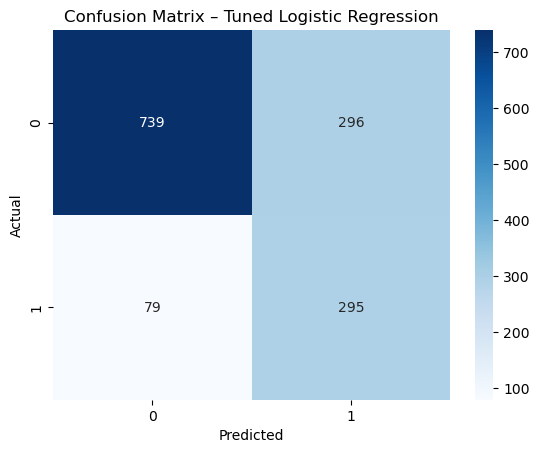

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance.head(10)


,Feature,Coefficient
11,InternetService_Fiber optic,1.251332
24,StreamingMovies_Yes,0.443285
22,StreamingTV_Yes,0.431726
10,MultipleLines_Yes,0.306937
3,TotalCharges,0.220216
29,PaymentMethod_Electronic check,0.187322
33,tenure_group_4-6yr,0.176896
27,PaperlessBilling_Yes,0.168646
18,DeviceProtection_Yes,0.136148
8,PhoneService_Yes,0.127537


In [ ]:
import joblib

joblib.dump(best_log_reg, "../models/logistic_regression_tuned.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']